carrier             0
airport             0
month               0
arr_flights         0
weather_ct          0
nas_ct              0
security_ct         0
late_aircraft_ct    0
weather_delay       0
nas_delay           0
carrier_delay       0
arr_delay           0
dtype: int64
Random Forest MSE: 5974861.713024343
Decision Tree MSE: 48538287.37037037


C:\Users\eliza\AppData\Local\Temp\ipykernel_74856\1753822458.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=model_results, palette='viridis')


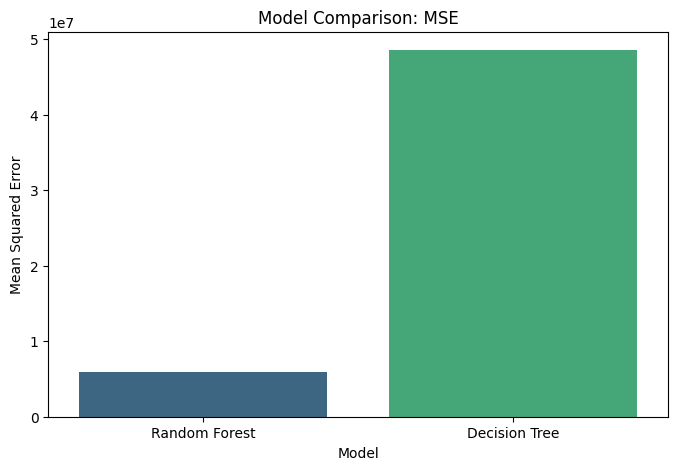

C:\Users\eliza\AppData\Local\Temp\ipykernel_74856\1753822458.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')


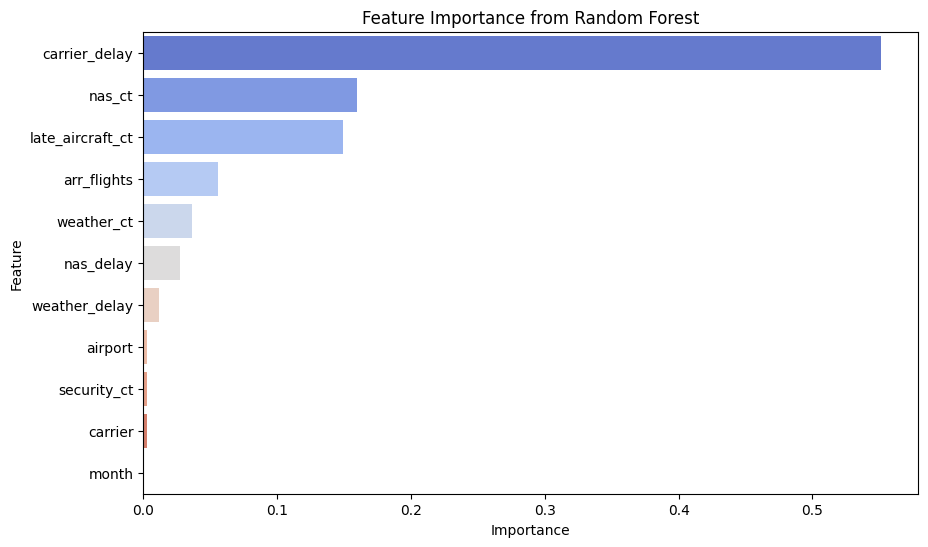

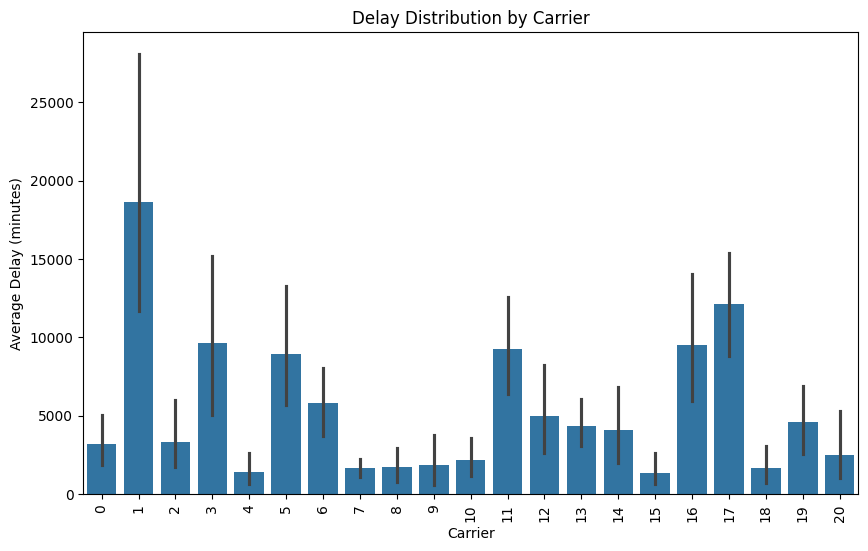

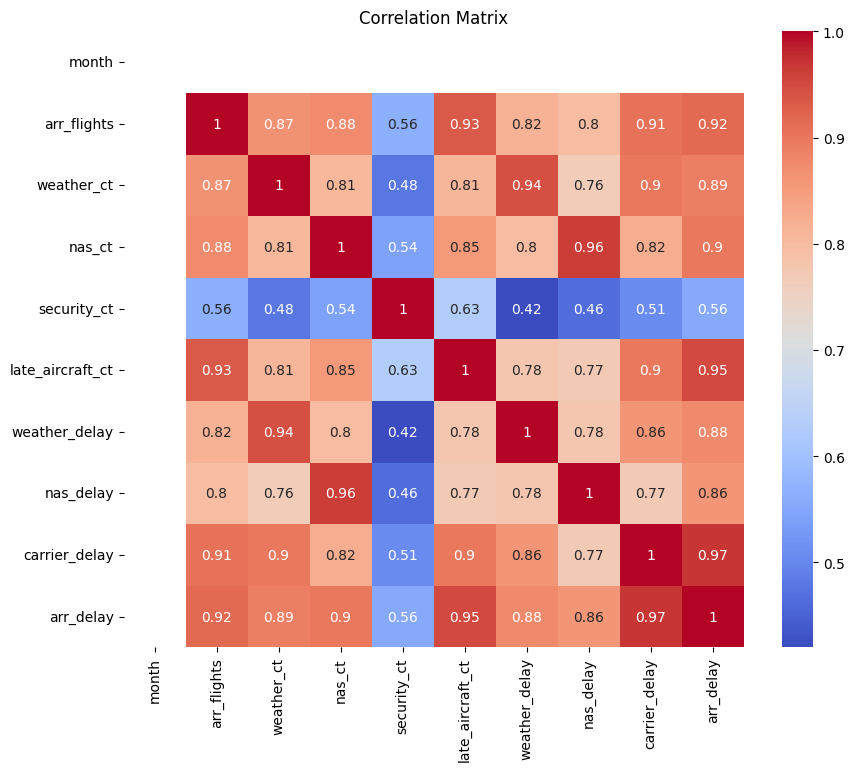

C:\Users\eliza\AppData\Local\Temp\ipykernel_74856\1753822458.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_delays.index, y=average_delays.values, palette='muted')


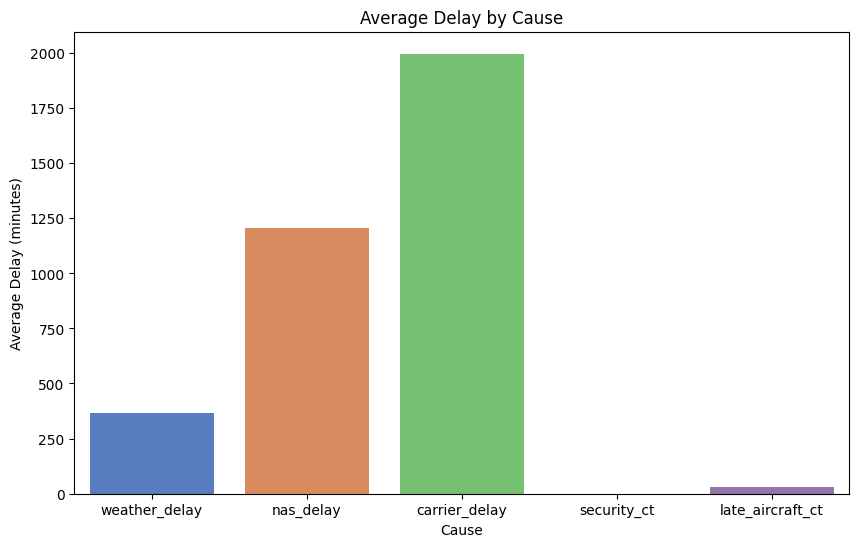

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Step 1: Load the dataset
file_path = 'Airline_Delay_Cause.csv'
data = pd.read_csv(file_path)

# Step 2: Inspect and select relevant features
features = ['carrier', 'airport', 'month', 'arr_flights', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'weather_delay', 'nas_delay', 'carrier_delay', 'arr_delay']
data = data[features]

# Step 3: Convert categorical columns to numerical
# Use .map() to avoid SettingWithCopyWarning
data['carrier'] = data['carrier'].astype('category').cat.codes
data['airport'] = data['airport'].astype('category').cat.codes

# Step 4: Check for missing values (there should be none as per your data preview)
print(data.isnull().sum())

# Step 5: Data preparation - Split the dataset into training and testing sets
X = data.drop('arr_delay', axis=1)  # Features
y = data['arr_delay']  # Target variable

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train models - Random Forest and Decision Tree
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Step 7: Model Evaluation - Mean Squared Error (MSE)
y_pred_rf = rf_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

# Compute MSE for both models
rf_mse = mean_squared_error(y_test, y_pred_rf)
dt_mse = mean_squared_error(y_test, y_pred_dt)

# Print MSE values
print(f"Random Forest MSE: {rf_mse}")
print(f"Decision Tree MSE: {dt_mse}")

# Step 8: Visualize Model Comparison (MSE)
model_results = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree'],
    'MSE': [rf_mse, dt_mse]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='MSE', data=model_results, palette='viridis')
plt.title('Model Comparison: MSE')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.show()

# Step 9: Visualize Feature Importance (for Random Forest)
feature_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Step 10: Visualize the distribution of delays by carrier
plt.figure(figsize=(10, 6))
sns.barplot(x='carrier', y='arr_delay', data=data)
plt.title('Delay Distribution by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=90)
plt.show()

# Step 11: Visualize the correlation between delay factors (only numeric columns)
numeric_data = data.select_dtypes(include=['float64', 'int64'])  # Select only numeric columns
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Step 12: New Simple Bar Graph - Average Delays by Cause
delay_factors = ['weather_delay', 'nas_delay', 'carrier_delay', 'security_ct', 'late_aircraft_ct']
average_delays = data[delay_factors].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=average_delays.index, y=average_delays.values, palette='muted')
plt.title('Average Delay by Cause')
plt.xlabel('Cause')
plt.ylabel('Average Delay (minutes)')
plt.show()
